# Santander Value Prediction - Data Preparation & Exploratory Analysis

## Project Overview

This notebook prepares the Santander Value Prediction dataset for machine learning.

### The preprocessing pipeline:

- Load training and test data
- Explore the target variable
- Remove constant features
- Remove duplicate features
- Create row-level statistical features
- Visualize engineered features
- Analyze feature correlations
- Prepare the final dataset for modeling

Import Libraries

In [17]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
ID_COL = "ID" 
TARGET = "target"

Load Dataset

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (4459, 4993)
test shape: (49342, 4992)


In [3]:
train.head()

,ID,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,000d6aaf2,38000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,000fbd867,600000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0027d6b71,10000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0028cbf45,2000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,002a68644,14400000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


Prepare Features

In [4]:
y = np.log1p(train[TARGET])

test_ids = test[ID_COL]

X = train.drop(columns=[ID_COL, TARGET])
X_test = test.drop(columns=[ID_COL])

Remove Constant Columns

In [5]:
constant_cols = []

for col in X.columns:
    if X[col].nunique() == 1:
        constant_cols.append(col)

print("removed", len(constant_cols), "constant columns")

X = X.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

removed 256 constant columns


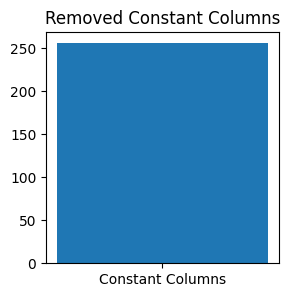

In [7]:
plt.figure(figsize=(3,3))
plt.bar(["Constant Columns"], [len(constant_cols)])
plt.title("Removed Constant Columns")
plt.show()

Remove Duplicate Columns

In [8]:
is_duplicate = X.T.duplicated()

duplicate_cols = X.columns[is_duplicate].tolist()

print("removed", len(duplicate_cols), "duplicate columns")

X = X.drop(columns=duplicate_cols)
X_test = X_test.drop(columns=duplicate_cols)

removed 5 duplicate columns


Add Row Features

In [9]:
values = X.values

X["row_sum"] = values.sum(axis=1)
X["row_mean"] = values.mean(axis=1)
X["row_std"] = values.std(axis=1)
X["row_min"] = values.min(axis=1)
X["row_max"] = values.max(axis=1)

X["row_nonzero_count"] = (values != 0).sum(axis=1)
X["row_zero_count"] = (values == 0).sum(axis=1)

nonzero = np.where(values == 0, np.nan, values)

X["row_nonzero_mean"] = np.nanmean(nonzero, axis=1)
X["row_nonzero_std"] = np.nanstd(nonzero, axis=1)
X["row_nonzero_min"] = np.nanmin(nonzero, axis=1)
X["row_nonzero_max"] = np.nanmax(nonzero, axis=1)

X = X.fillna(0)

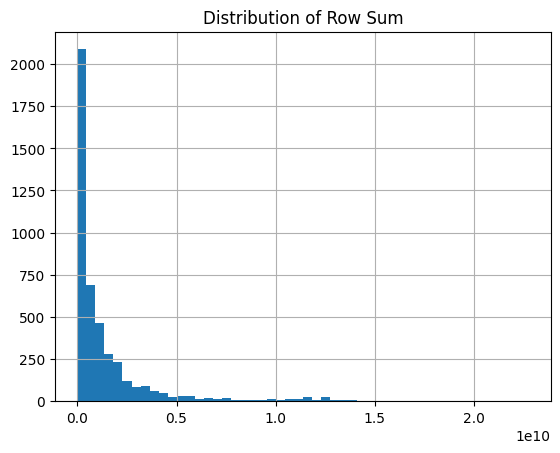

In [10]:
X["row_sum"].hist(bins=50)
plt.title("Distribution of Row Sum")
plt.show()

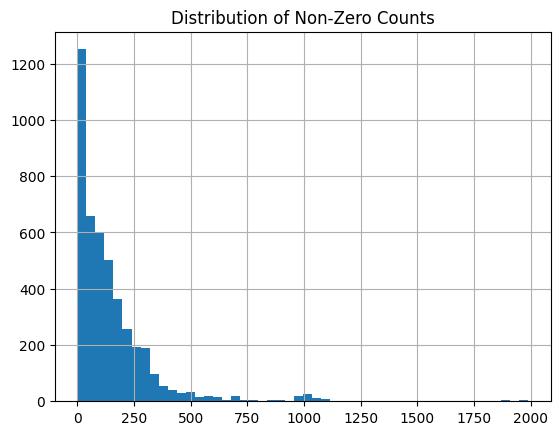

In [12]:
X["row_nonzero_count"].hist(bins=50)
plt.title("Distribution of Non-Zero Counts")
plt.show()

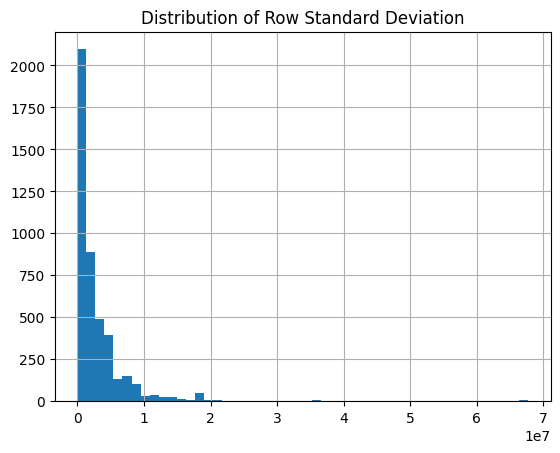

In [13]:
X["row_std"].hist(bins=50)
plt.title("Distribution of Row Standard Deviation")
plt.show()

In [14]:
print("final train shape:", X.shape)
print("final test shape:", X_test.shape)

final train shape: (4459, 4741)
final test shape: (49342, 4730)


In [15]:
X.head()

,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,dc5a8f1d8,...,row_mean,row_std,row_min,row_max,row_nonzero_count,row_zero_count,row_nonzero_mean,row_nonzero_std,row_nonzero_min,row_nonzero_max
0,0.0,0,0.0,0,0,0,0,0,0.0,0.0,...,152382.311484,1.788138e+06,0.0,40000000.0,102,4628,7.066356e+06,9.970794e+06,250000.0,40000000.0
1,0.0,0,0.0,0,0,0,0,0,2200000.0,0.0,...,112466.525725,1.570552e+06,0.0,50000000.0,67,4663,7.939801e+06,1.058251e+07,800000.0,50000000.0
2,0.0,0,0.0,0,0,0,0,0,0.0,0.0,...,16109.936575,3.403743e+05,0.0,12000000.0,18,4712,4.233333e+06,3.548396e+06,200000.0,12000000.0
3,0.0,0,0.0,0,0,0,0,0,0.0,0.0,...,7059.337560,1.785048e+05,0.0,6000000.0,22,4708,1.517758e+06,2.134919e+06,2000.0,6000000.0
4,0.0,0,0.0,0,0,0,0,0,2000000.0,0.0,...,37778.858351,8.712355e+05,0.0,37662000.0,26,4704,6.872846e+06,9.545291e+06,60000.0,37662000.0


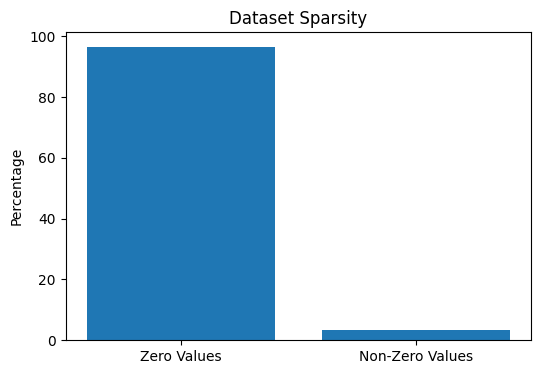

In [16]:
zero_ratio = (
    (X == 0).sum().sum()
    / (X.shape[0] * X.shape[1])
)

plt.figure(figsize=(6,4))

plt.bar(
    ["Zero Values", "Non-Zero Values"],
    [zero_ratio * 100,
     (1 - zero_ratio) * 100]
)

plt.ylabel("Percentage")
plt.title("Dataset Sparsity")
plt.show()

After preparing the data, we train a LightGBM model using
5-fold cross-validation.

Cross-validation helps estimate model performance by training
on different subsets of the data and validating on unseen folds.

Evaluation Metric

In [18]:
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

LightGBM Parameters

In [19]:
RANDOM_STATE = 42

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.01,
    "num_leaves": 64,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "feature_fraction": 0.8,
    "lambda_l1": 1.0,
    "lambda_l2": 1.0,
    "seed": RANDOM_STATE,
    "num_threads": -1,
    "verbose": -1,
}

KFold Setup

In [20]:
folds = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []
best_iterations = []

Training Loop

In [22]:
X, X_test = X.align(X_test, join="inner", axis=1)

In [23]:
for fold, (train_idx, valid_idx) in enumerate(folds.split(X), 1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_valid, label=y_valid)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=5000,
        valid_sets=[dvalid],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    valid_preds = model.predict(
        X_valid,
        num_iteration=model.best_iteration
    )

    oof[valid_idx] = valid_preds

    score = rmsle(y_valid, valid_preds)

    fold_scores.append(score)
    best_iterations.append(model.best_iteration)

    print(f"Fold {fold} RMSLE: {score:.5f} | Trees: {model.best_iteration}")

    test_preds += model.predict(
        X_test,
        num_iteration=model.best_iteration
    ) / 5

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[304]	valid_0's rmse: 1.41145
Fold 1 RMSLE: 1.41145 | Trees: 304
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[415]	valid_0's rmse: 1.44086
Fold 2 RMSLE: 1.44086 | Trees: 415
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[377]	valid_0's rmse: 1.42381
Fold 3 RMSLE: 1.42381 | Trees: 377
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[497]	valid_0's rmse: 1.41092
Fold 4 RMSLE: 1.41092 | Trees: 497
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[421]	valid_0's rmse: 1.37778
Fold 5 RMSLE: 1.37778 | Trees: 421


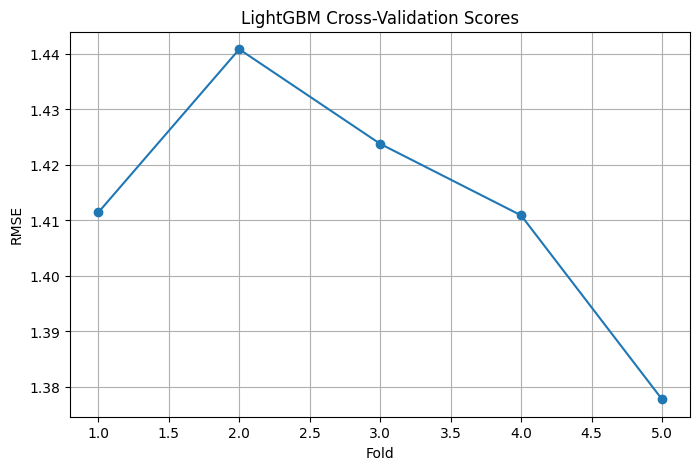

In [24]:
import matplotlib.pyplot as plt

folds = [1, 2, 3, 4, 5]
scores = [1.41145, 1.44086, 1.42381, 1.41092, 1.37778]

plt.figure(figsize=(8,5))

plt.plot(folds, scores, marker="o")

plt.title("LightGBM Cross-Validation Scores")
plt.xlabel("Fold")
plt.ylabel("RMSE")

plt.grid()
plt.show()

Overall CV Score

In [25]:
overall_score = rmsle(y, oof)

print("Overall CV RMSLE:", overall_score)

Overall CV RMSLE: 1.4131213927471646


Actual vs Predicted

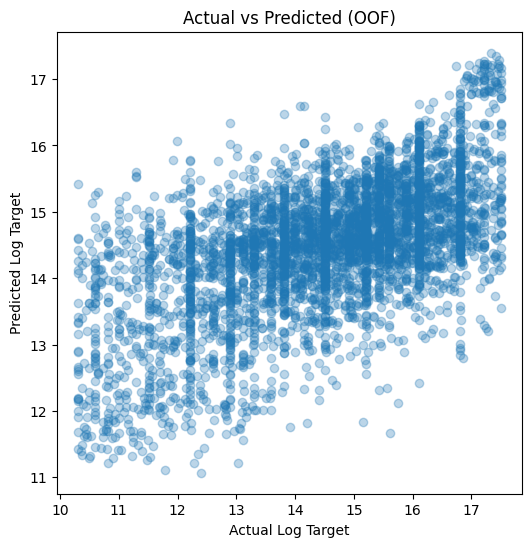

In [27]:
plt.figure(figsize=(6,6))

plt.scatter(y, oof, alpha=0.3)

plt.title("Actual vs Predicted (OOF)")
plt.xlabel("Actual Log Target")
plt.ylabel("Predicted Log Target")

plt.show()

Build Submission

In [ ]:
submission = pd.DataFrame({
    "ID": test_ids,
    "target": np.expm1(test_preds)
})

submission["target"] = submission["target"].clip(lower=0)

submission.head()
submission.to_csv("submission.csv", index=False)

print("submission.csv saved")